<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/05-CIFAR-10/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [4]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [5]:
print("X_Train", X_train.shape)
print("y_train",y_train.shape)

X_Train (50000, 32, 32, 3)
y_train (50000, 1)


In [6]:
x_train = X_train.reshape(X_train.shape[0], -1)
x_test = X_test.reshape(X_test.shape[0], -1)
y_train=y_train.ravel()
y_test=y_test.ravel()
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 3072)
(10000, 3072)
(50000,)
(10000,)


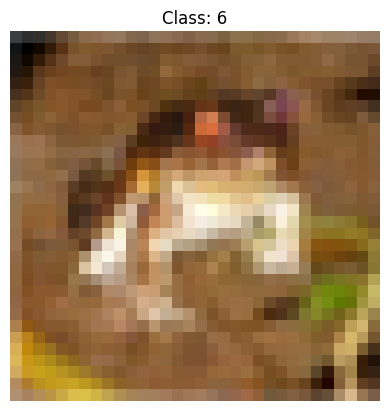

In [7]:
plt.imshow(x_train[0].reshape(32,32,3))
plt.title(f"Class: {y_train[0]}")
plt.axis("off")
plt.show()

# **Finding Best PCA parameter**

## **Using StandardScaler**

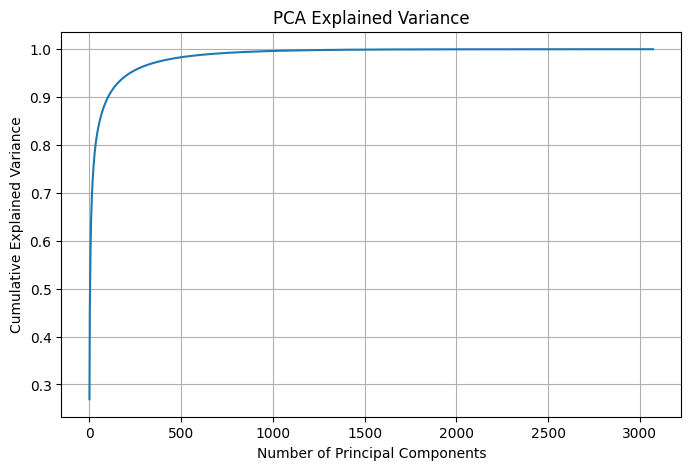

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()

plt.show()

In [9]:
threshold = 0.99

n_components_99 = np.argmax(
    cumulative_variance >= threshold
) + 1

print(
    "\nComponents required for 99% variance:",
    n_components_99
)



Components required for 99% variance: 662


## **Using MinMax Scaler**

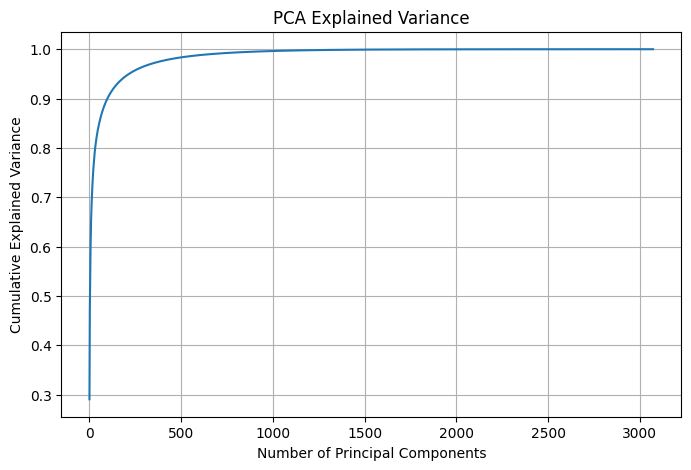

In [10]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(x_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()

plt.show()

In [11]:
threshold = 0.99

n_components_99 = np.argmax(
    cumulative_variance >= threshold
) + 1

print(
    "\nComponents required for 99% variance:",
    n_components_99
)



Components required for 99% variance: 658


# **Standard Scaler+PCA+Logistic Regression**

In [12]:
pipe1=Pipeline([
    ("scale",StandardScaler()),
    ("pca",PCA(n_components=662)),
    ('lr',LogisticRegression(max_iter=10000))
])

In [13]:
pipe1.fit(x_train,y_train)

Pipeline(steps=[('scale', StandardScaler()), ('pca', PCA(n_components=662)),
                ('lr', LogisticRegression(max_iter=10000))])

In [14]:
y_pred_1=pipe1.predict(x_test)

In [15]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_1))


Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.49      0.47      1000
           1       0.47      0.47      0.47      1000
           2       0.32      0.29      0.30      1000
           3       0.28      0.26      0.27      1000
           4       0.35      0.29      0.32      1000
           5       0.33      0.33      0.33      1000
           6       0.41      0.47      0.44      1000
           7       0.44      0.44      0.44      1000
           8       0.50      0.53      0.51      1000
           9       0.45      0.47      0.46      1000

    accuracy                           0.40     10000
   macro avg       0.40      0.40      0.40     10000
weighted avg       0.40      0.40      0.40     10000



# **MinMax Scaler+PCA+Logistic Regression**

In [18]:
pipe2=pipe2=Pipeline([
    ('scale',MinMaxScaler()),
    ('pca',PCA(n_components=658)),
    ('lr',LogisticRegression(max_iter=10000))
])

In [20]:
pipe2.fit(x_train,y_train)

Pipeline(steps=[('scale', MinMaxScaler()), ('pca', PCA(n_components=658)),
                ('lr', LogisticRegression(max_iter=10000))])

In [21]:
y_pred_2=pipe2.predict(x_test)

In [22]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_2))


Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.49      0.47      1000
           1       0.46      0.46      0.46      1000
           2       0.31      0.27      0.29      1000
           3       0.27      0.25      0.26      1000
           4       0.36      0.30      0.32      1000
           5       0.33      0.34      0.34      1000
           6       0.40      0.46      0.43      1000
           7       0.46      0.45      0.45      1000
           8       0.50      0.54      0.52      1000
           9       0.44      0.47      0.45      1000

    accuracy                           0.40     10000
   macro avg       0.40      0.40      0.40     10000
weighted avg       0.40      0.40      0.40     10000



# **StandarScaler+PCA+SVM**

In [23]:
pipe4=Pipeline([
    ('scale',StandardScaler()),
    ('pca',PCA(n_components=662)),
    ('svm',SVC(kernel='rbf',C=10))
])

In [24]:
pipe4.fit(x_train,y_train)

Pipeline(steps=[('scale', StandardScaler()), ('pca', PCA(n_components=662)),
                ('svm', SVC(C=10))])

In [25]:
y_pred_4=pipe4.predict(x_test)

In [26]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_4))


Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.65      1000
           1       0.65      0.68      0.67      1000
           2       0.45      0.47      0.46      1000
           3       0.39      0.42      0.40      1000
           4       0.51      0.49      0.50      1000
           5       0.51      0.46      0.48      1000
           6       0.63      0.62      0.62      1000
           7       0.66      0.59      0.63      1000
           8       0.71      0.69      0.70      1000
           9       0.63      0.62      0.63      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



# **MinMaxScaler+PCA+SVM**

In [27]:
pipe3=Pipeline([
    ('scale',MinMaxScaler()),
    ('pca',PCA(n_components=658)),
    ('svm',SVC(kernel='rbf',C=10))
])

In [28]:
pipe3.fit(x_train,y_train)

Pipeline(steps=[('scale', MinMaxScaler()), ('pca', PCA(n_components=658)),
                ('svm', SVC(C=10))])

In [29]:
y_pred_3=pipe3.predict(x_test)

In [30]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_3))


Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.64      1000
           1       0.65      0.68      0.66      1000
           2       0.45      0.47      0.46      1000
           3       0.38      0.41      0.39      1000
           4       0.50      0.48      0.49      1000
           5       0.49      0.46      0.48      1000
           6       0.62      0.61      0.61      1000
           7       0.66      0.58      0.62      1000
           8       0.71      0.69      0.70      1000
           9       0.62      0.63      0.63      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000

